# Data Understanding

Inspection only: the raw dataset is not modified or preprocessed, and no model is trained. `Fraudulent = 0` means legitimate; `Fraudulent = 1` means fraudulent.

## Load Dataset

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

candidate_paths = [
    Path("data/raw/fraud_detection.csv"),
    Path("../data/raw/fraud_detection.csv"),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find data/raw/fraud_detection.csv")

DATA_PATH.resolve()

WindowsPath('C:/Users/Priya Koma/Desktop/AI_ML_Assessments/ai_fraud_detection_poc/data/raw/fraud_detection.csv')

In [ ]:
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")

Dataset loaded successfully.


## Dataset Overview

In [ ]:
row_count, column_count = df.shape
print(f"Rows: {row_count:,}")
print(f"Columns: {column_count}")

Rows: 51,000
Columns: 12


In [ ]:
display(df.head())
display(df.tail())

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,"1,292.76",ATM Withdrawal,16.00,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,"1,554.58",ATM Withdrawal,13.00,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,"2,395.02",ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.00,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,"1,490.50",POS Payment,19.00,Mobile,San Francisco,2,57,7,Credit Card,0


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50995,T33982,2339,"3,112.51",Bill Payment,15.00,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,"2,897.15",Online Purchase,3.00,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,"2,204.43",POS Payment,18.00,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,"4,787.17",POS Payment,19.00,Tablet,New York,2,108,14,Net Banking,0
50999,T13665,2315,814.72,POS Payment,3.00,Tablet,Los Angeles,0,50,10,Invalid Method,0


In [ ]:
for position, column in enumerate(df.columns, start=1):
    print(f"{position:>2}. {column}")

 1. Transaction_ID
 2. User_ID
 3. Transaction_Amount
 4. Transaction_Type
 5. Time_of_Transaction
 6. Device_Used
 7. Location
 8. Previous_Fraudulent_Transactions
 9. Account_Age
10. Number_of_Transactions_Last_24H
11. Payment_Method
12. Fraudulent


In [ ]:
display(df.dtypes.rename("dtype").to_frame())
df.info()

,dtype
Transaction_ID,str
User_ID,int64
Transaction_Amount,float64
Transaction_Type,str
Time_of_Transaction,float64
Device_Used,str
Location,str
Previous_Fraudulent_Transactions,int64
Account_Age,int64
Number_of_Transactions_Last_24H,int64


<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  str    
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  str    
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  str    
 6   Location                          48453 non-null  str    
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  str    
 11  Fraudulent                        51000 non-null  int64  
dtypes: float64(2), 

In [ ]:
display(df.describe(include="number").T)

,count,mean,std,min,25%,50%,75%,max
User_ID,"51,000.00","3,005.11","1,153.12","1,000.00","2,007.00","2,996.00","4,006.00","4,999.00"
Transaction_Amount,"48,480.00","2,996.25","5,043.93",5.03,"1,270.55","2,524.10","3,787.24","49,997.80"
Time_of_Transaction,"48,448.00",11.49,6.92,0.00,5.00,12.00,17.00,23.00
Previous_Fraudulent_Transactions,"51,000.00",2.00,1.42,0.00,1.00,2.00,3.00,4.00
Account_Age,"51,000.00",60.03,34.38,1.00,30.00,60.00,90.00,119.00
Number_of_Transactions_Last_24H,"51,000.00",7.50,4.02,1.00,4.00,7.00,11.00,14.00
Fraudulent,"51,000.00",0.05,0.22,0.00,0.00,0.00,0.00,1.00


## Missing Values

,missing_count,missing_percentage
Time_of_Transaction,2552,5.00
Location,2547,4.99
Transaction_Amount,2520,4.94
Device_Used,2473,4.85
Payment_Method,2469,4.84
Transaction_ID,0,0.00
User_ID,0,0.00
Transaction_Type,0,0.00
Previous_Fraudulent_Transactions,0,0.00
Account_Age,0,0.00


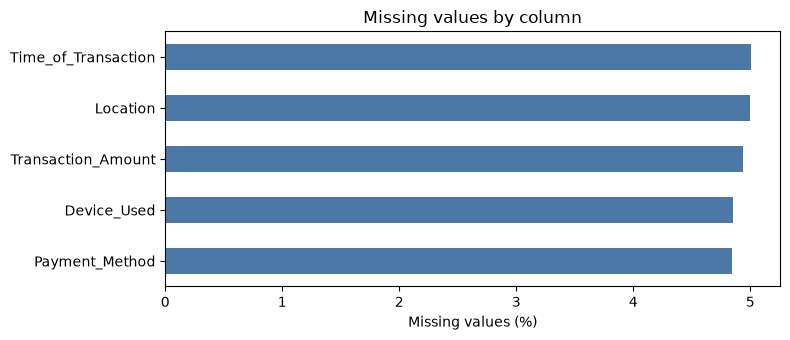

In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean().mul(100),
}).sort_values(["missing_count", "missing_percentage"], ascending=False)
display(missing_summary)

missing_to_plot = missing_summary.query("missing_count > 0").sort_values("missing_percentage")
if not missing_to_plot.empty:
    ax = missing_to_plot["missing_percentage"].plot.barh(figsize=(8, 3.5), color="#4C78A8")
    ax.set(title="Missing values by column", xlabel="Missing values (%)", ylabel="")
    plt.tight_layout()
    plt.show()

## Duplicate Analysis

In [ ]:
exact_duplicate_extra_count = int(df.duplicated().sum())
exact_duplicate_all_count = int(df.duplicated(keep=False).sum())
print(f"Extra exact duplicate rows beyond their first occurrences: {exact_duplicate_extra_count:,}")
print(f"All rows that belong to exact-duplicate groups: {exact_duplicate_all_count:,}")
display(df.loc[df.duplicated(keep=False)].sort_values("Transaction_ID").head(10))

Extra exact duplicate rows beyond their first occurrences: 881
All rows that belong to exact-duplicate groups: 1,762


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50688,T1004,4190,"2,828.74",Bill Payment,21.00,Tablet,Boston,2,97,14,Credit Card,0
1003,T1004,4190,"2,828.74",Bill Payment,21.00,Tablet,Boston,2,97,14,Credit Card,0
50440,T10075,3686,"3,700.47",ATM Withdrawal,7.00,Mobile,San Francisco,1,38,10,Net Banking,0
10074,T10075,3686,"3,700.47",ATM Withdrawal,7.00,Mobile,San Francisco,1,38,10,Net Banking,0
10075,T10076,2798,"1,775.37",Online Purchase,NaN,Desktop,Seattle,4,33,4,Credit Card,1
50952,T10076,2798,"1,775.37",Online Purchase,NaN,Desktop,Seattle,4,33,4,Credit Card,1
50494,T10193,1225,NaN,ATM Withdrawal,5.00,Tablet,Los Angeles,1,74,13,UPI,0
10192,T10193,1225,NaN,ATM Withdrawal,5.00,Tablet,Los Angeles,1,74,13,UPI,0
1030,T1031,1475,"2,498.40",Bill Payment,8.00,Mobile,New York,2,56,13,Credit Card,0
50447,T1031,1475,"2,498.40",Bill Payment,8.00,Mobile,New York,2,56,13,Credit Card,0


In [ ]:
transaction_id_counts = df["Transaction_ID"].value_counts(dropna=False)
repeated_transaction_ids = transaction_id_counts[transaction_id_counts > 1]
transaction_duplicate_rows = df[df["Transaction_ID"].duplicated(keep=False)]
conflicting_transaction_ids = (
    transaction_duplicate_rows.groupby("Transaction_ID", dropna=False)
    .nunique(dropna=False)
    .drop(columns="Transaction_ID", errors="ignore")
    .gt(1)
    .any(axis=1)
)
print(f"Unique Transaction_ID values: {df['Transaction_ID'].nunique(dropna=False):,}")
print(f"Transaction_ID values occurring more than once: {len(repeated_transaction_ids):,}")
print(f"Rows carrying a repeated Transaction_ID: {len(transaction_duplicate_rows):,}")
print(f"Repeated Transaction_ID values with conflicting row content: {int(conflicting_transaction_ids.sum()):,}")
display(repeated_transaction_ids.describe().rename("repeated_ID_frequency").to_frame())
display(transaction_duplicate_rows.sort_values("Transaction_ID").head(10))

Unique Transaction_ID values: 50,000
Transaction_ID values occurring more than once: 1,000
Rows carrying a repeated Transaction_ID: 2,000
Repeated Transaction_ID values with conflicting row content: 119


,repeated_ID_frequency
count,"1,000.00"
mean,2.00
std,0.00
min,2.00
25%,2.00
50%,2.00
75%,2.00
max,2.00


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50688,T1004,4190,"2,828.74",Bill Payment,21.00,Tablet,Boston,2,97,14,Credit Card,0
1003,T1004,4190,"2,828.74",Bill Payment,21.00,Tablet,Boston,2,97,14,Credit Card,0
50440,T10075,3686,"3,700.47",ATM Withdrawal,7.00,Mobile,San Francisco,1,38,10,Net Banking,0
10074,T10075,3686,"3,700.47",ATM Withdrawal,7.00,Mobile,San Francisco,1,38,10,Net Banking,0
50952,T10076,2798,"1,775.37",Online Purchase,NaN,Desktop,Seattle,4,33,4,Credit Card,1
10075,T10076,2798,"1,775.37",Online Purchase,NaN,Desktop,Seattle,4,33,4,Credit Card,1
10192,T10193,1225,NaN,ATM Withdrawal,5.00,Tablet,Los Angeles,1,74,13,UPI,0
50494,T10193,1225,NaN,ATM Withdrawal,5.00,Tablet,Los Angeles,1,74,13,UPI,0
50447,T1031,1475,"2,498.40",Bill Payment,8.00,Mobile,New York,2,56,13,Credit Card,0
1030,T1031,1475,"2,498.40",Bill Payment,8.00,Mobile,New York,2,56,13,Credit Card,0


## Target Distribution

Class imbalance is assessed explicitly because accuracy alone is misleading for fraud detection.

,count
Fraudulent,
Legitimate (0),48490
Fraudulent (1),2510


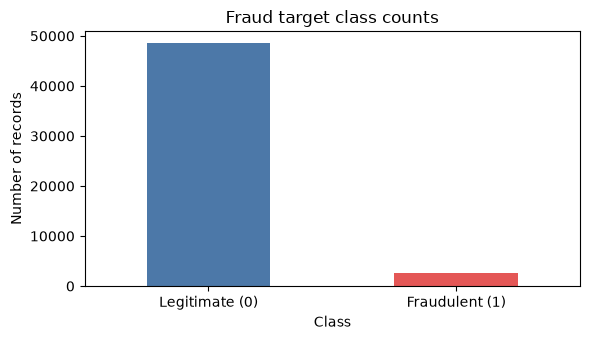

In [ ]:
target_labels = {0: "Legitimate (0)", 1: "Fraudulent (1)"}
target_counts = df["Fraudulent"].value_counts(dropna=False).sort_index()
target_count_table = target_counts.rename(index=target_labels).rename("count").to_frame()
display(target_count_table)

ax = target_count_table["count"].plot.bar(figsize=(6, 3.5), color=["#4C78A8", "#E45756"], rot=0)
ax.set(title="Fraud target class counts", xlabel="Class", ylabel="Number of records")
plt.tight_layout()
plt.show()

In [ ]:
target_percentages = target_counts.div(len(df)).mul(100)
target_percentage_table = target_percentages.rename(index=target_labels).rename("percentage").to_frame()
display(target_percentage_table)
print(f"Majority-class accuracy if every record were predicted legitimate: {target_percentages.loc[0]:.2f}%")
print("This high-looking value would detect no fraudulent transactions, so accuracy alone is unsuitable.")

,percentage
Fraudulent,
Legitimate (0),95.08
Fraudulent (1),4.92


Majority-class accuracy if every record were predicted legitimate: 95.08%
This high-looking value would detect no fraudulent transactions, so accuracy alone is unsuitable.


## Numerical and Categorical Features

,count,mean,std,min,25%,50%,75%,max
Transaction_Amount,"48,480.00","2,996.25","5,043.93",5.03,"1,270.55","2,524.10","3,787.24","49,997.80"
Time_of_Transaction,"48,448.00",11.49,6.92,0.00,5.00,12.00,17.00,23.00
Previous_Fraudulent_Transactions,"51,000.00",2.00,1.42,0.00,1.00,2.00,3.00,4.00
Account_Age,"51,000.00",60.03,34.38,1.00,30.00,60.00,90.00,119.00
Number_of_Transactions_Last_24H,"51,000.00",7.50,4.02,1.00,4.00,7.00,11.00,14.00


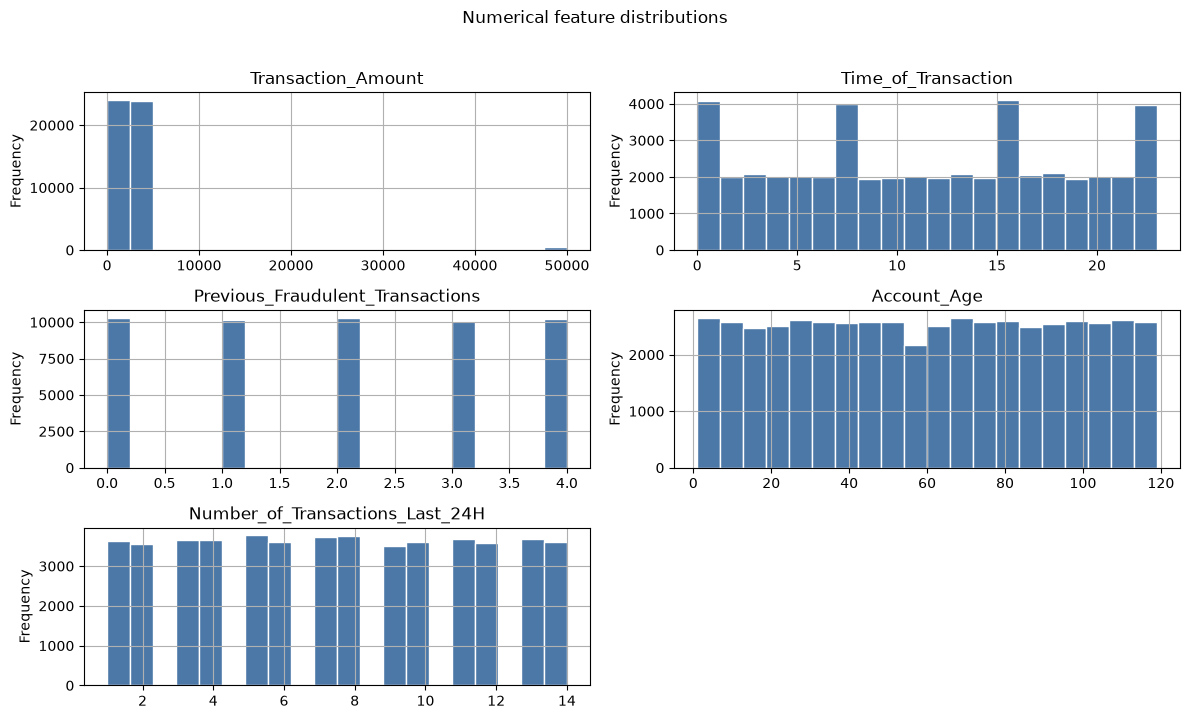

In [ ]:
identifier_columns = ["Transaction_ID", "User_ID"]
target_column = "Fraudulent"
numerical_features = [
    column for column in df.select_dtypes(include="number").columns
    if column not in identifier_columns + [target_column]
]
display(df[numerical_features].describe().T)

axes = df[numerical_features].hist(figsize=(12, 7), bins=20, color="#4C78A8", edgecolor="white")
for axis in axes.ravel():
    axis.set_ylabel("Frequency")
plt.suptitle("Numerical feature distributions", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
categorical_features = [
    column for column in df.select_dtypes(include=["object", "string", "category"]).columns
    if column != "Transaction_ID"
]
for column in categorical_features:
    print(f"\n{column}")
    counts = df[column].value_counts(dropna=False)
    display(pd.DataFrame({"count": counts, "percentage": counts.div(len(df)).mul(100)}))


Transaction_Type


,count,percentage
Transaction_Type,,
Bill Payment,10340,20.27
Bank Transfer,10276,20.15
ATM Withdrawal,10164,19.93
POS Payment,10126,19.85
Online Purchase,10094,19.79



Device_Used


,count,percentage
Device_Used,,
Desktop,15795,30.97
Mobile,15614,30.62
Tablet,15588,30.56
NaN,2473,4.85
Unknown Device,1530,3.00



Location


,count,percentage
Location,,
Boston,6149,12.06
New York,6110,11.98
Seattle,6104,11.97
Chicago,6071,11.90
Houston,6031,11.83
Los Angeles,6012,11.79
Miami,5991,11.75
San Francisco,5985,11.74
NaN,2547,4.99



Payment_Method


,count,percentage
Payment_Method,,
UPI,11887,23.31
Debit Card,11802,23.14
Net Banking,11666,22.87
Credit Card,11646,22.84
NaN,2469,4.84
Invalid Method,1530,3.00


In [ ]:
cardinality = pd.DataFrame({
    "unique_values_including_missing": df.nunique(dropna=False),
    "unique_percentage_of_rows": df.nunique(dropna=False).div(len(df)).mul(100),
}).sort_values("unique_values_including_missing", ascending=False)
display(cardinality)

,unique_values_including_missing,unique_percentage_of_rows
Transaction_ID,50000,98.04
Transaction_Amount,44822,87.89
User_ID,4000,7.84
Account_Age,119,0.23
Time_of_Transaction,25,0.05
Number_of_Transactions_Last_24H,14,0.03
Location,9,0.02
Payment_Method,6,0.01
Transaction_Type,5,0.01
Device_Used,5,0.01


## Feature vs Target Analysis

In [ ]:
numerical_by_target = df.groupby(target_column)[numerical_features].agg(["count", "mean", "median"])
numerical_by_target.index = numerical_by_target.index.map(target_labels)
display(numerical_by_target.T)

for column in categorical_features:
    analysis_frame = df.assign(**{column: df[column].fillna("<MISSING>")})
    category_target = analysis_frame.groupby(column, dropna=False)[target_column].agg(
        record_count="size", fraudulent_count="sum", fraud_rate="mean"
    )
    category_target["fraud_rate_percentage"] = category_target["fraud_rate"].mul(100)
    print(f"\n{column} versus Fraudulent")
    display(category_target.drop(columns="fraud_rate").sort_values("fraud_rate_percentage", ascending=False))

Fraudulent                               Legitimate (0)  Fraudulent (1)
Transaction_Amount               count        46,095.00        2,385.00
                                 mean          2,989.93        3,118.37
                                 median        2,524.39        2,516.01
Time_of_Transaction              count        46,072.00        2,376.00
                                 mean             11.48           11.70
                                 median           12.00           12.00
Previous_Fraudulent_Transactions count        48,490.00        2,510.00
                                 mean              2.00            2.00
                                 median            2.00            2.00
Account_Age                      count        48,490.00        2,510.00
                                 mean             59.99           60.97
                                 median           60.00           62.00
Number_of_Transactions_Last_24H  count        48,490.00        2,510.00
                                 mean              7.50            7.43
                                 median            7.00            7.00


Transaction_Type versus Fraudulent


,record_count,fraudulent_count,fraud_rate_percentage
Transaction_Type,,,
Online Purchase,10094,524,5.19
POS Payment,10126,507,5.01
Bill Payment,10340,512,4.95
Bank Transfer,10276,494,4.81
ATM Withdrawal,10164,473,4.65



Device_Used versus Fraudulent


,record_count,fraudulent_count,fraud_rate_percentage
Device_Used,,,
<MISSING>,2473,152,6.15
Mobile,15614,806,5.16
Unknown Device,1530,75,4.90
Desktop,15795,748,4.74
Tablet,15588,729,4.68



Location versus Fraudulent


,record_count,fraudulent_count,fraud_rate_percentage
Location,,,
Chicago,6071,334,5.50
Los Angeles,6012,310,5.16
Boston,6149,310,5.04
Miami,5991,298,4.97
San Francisco,5985,297,4.96
<MISSING>,2547,123,4.83
New York,6110,290,4.75
Houston,6031,282,4.68
Seattle,6104,266,4.36



Payment_Method versus Fraudulent


,record_count,fraudulent_count,fraud_rate_percentage
Payment_Method,,,
UPI,11887,612,5.15
Credit Card,11646,574,4.93
Net Banking,11666,574,4.92
Debit Card,11802,572,4.85
Invalid Method,1530,73,4.77
<MISSING>,2469,105,4.25


## Data Leakage Checks

`Transaction_ID` and `User_ID` are treated as identifiers. `Previous_Fraudulent_Transactions` requires an as-of-time definition to confirm that it contains only information available before the current transaction.

In [ ]:
previous_fraud_analysis = df.groupby(target_column)["Previous_Fraudulent_Transactions"].agg(
    ["count", "mean", "median", "min", "max"]
)
previous_fraud_analysis.index = previous_fraud_analysis.index.map(target_labels)
display(previous_fraud_analysis)
display(pd.crosstab(
    df["Previous_Fraudulent_Transactions"],
    df[target_column].map(target_labels),
    margins=True,
))

user_summary = df.groupby("User_ID")[target_column].agg(
    transaction_count="size", fraudulent_count="sum", fraud_rate="mean"
)
print(f"Unique users: {len(user_summary):,}")
print(f"Users appearing in more than one row: {(user_summary['transaction_count'] > 1).sum():,}")
print(f"Users with at least one legitimate and one fraudulent record: {((user_summary['fraudulent_count'] > 0) & (user_summary['fraudulent_count'] < user_summary['transaction_count'])).sum():,}")
display(user_summary.describe())

print("Transaction_ID is an identifier and must be excluded from predictive features.")
print("User_ID is also treated as an identifier unless a future experiment explicitly justifies a leakage-safe representation.")

,count,mean,median,min,max
Fraudulent,,,,,
Legitimate (0),48490,2.00,2.00,0,4
Fraudulent (1),2510,2.00,2.00,0,4


Fraudulent,Fraudulent (1),Legitimate (0),All
Previous_Fraudulent_Transactions,,,
0,483,9797,10280
1,519,9612,10131
2,512,9809,10321
3,500,9563,10063
4,496,9709,10205
All,2510,48490,51000


Unique users: 4,000
Users appearing in more than one row: 4,000
Users with at least one legitimate and one fraudulent record: 1,857


,transaction_count,fraudulent_count,fraud_rate
count,"4,000.00","4,000.00","4,000.00"
mean,12.75,0.63,0.05
std,3.62,0.80,0.06
min,2.00,0.00,0.00
25%,10.00,0.00,0.00
50%,13.00,0.00,0.00
75%,15.00,1.00,0.08
max,28.00,5.00,0.50


Transaction_ID is an identifier and must be excluded from predictive features.
User_ID is also treated as an identifier unless a future experiment explicitly justifies a leakage-safe representation.


## Data Understanding Conclusions

In [ ]:
quality_observations = pd.Series({
    "Rows": len(df),
    "Columns": df.shape[1],
    "Columns with missing values": int(df.isna().any().sum()),
    "Total missing cells": int(df.isna().sum().sum()),
    "Extra exact duplicate rows": exact_duplicate_extra_count,
    "Repeated Transaction_ID values": len(repeated_transaction_ids),
    "Conflicting repeated Transaction_ID values": int(conflicting_transaction_ids.sum()),
    "Unique User_ID values": df["User_ID"].nunique(dropna=False),
    "Fraudulent rows": int((df[target_column] == 1).sum()),
    "Unexpected target values": int((~df[target_column].isin([0, 1])).sum()),
})
display(quality_observations.rename("value").to_frame())

,value
Rows,51000
Columns,12
Columns with missing values,5
Total missing cells,12561
Extra exact duplicate rows,881
Repeated Transaction_ID values,1000
Conflicting repeated Transaction_ID values,119
Unique User_ID values,4000
Fraudulent rows,2510
Unexpected target values,0


- **Dataset:** 51,000 rows and 12 columns.
- **Target imbalance:** 48,490 legitimate records (95.08%) and 2,510 fraudulent records (4.92%); accuracy alone is unsuitable.
- **Missing data:** five columns have approximately 4.8%–5.0% missing values; causes must be understood before selecting a treatment.
- **Duplicates:** 881 extra exact duplicate rows were found. There are 1,000 repeated `Transaction_ID` values, including 119 with conflicting row content.
- **Identifiers:** `Transaction_ID` must be excluded from predictive features. `User_ID` is also treated as an identifier unless a leakage-safe use is explicitly justified.
- **Leakage risk:** `Previous_Fraudulent_Transactions` does not show obvious univariate target separation, but its timing and definition must be verified. Repeated users require group-aware and/or time-aware evaluation splits.
- **Before preprocessing:** resolve missing-value causes, conflicting transaction records, record authority, feature timing, and the appropriate user/time-based split strategy.